In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
from scipy.stats import zscore
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef

How this anndata was made:
* Started from /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad
    * https://github.com/CooperStansbury/hematokytos/blob/main/notebooks/summary/intergration_hsc_scfib.ipynb
    * Integrated and processed HSC and scFib data
* Then became /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad
    * https://github.com/CooperStansbury/hematokytos/blob/main/notebooks/trajectory_inference/make_pseudotime.ipynb
    * Scored cell cycle genes (Regev genes, on log_norm layer), computed diffusion pseudotime
* Then became /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle_velocity.h5ad
    * https://github.com/CooperStansbury/cell_cycle/blob/main/notebooks/buid_velocity_data.ipynb
    * Filtered for just scFib, added scVelo layers 
* Then became /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/imputed.h5ad
    * https://github.com/CooperStansbury/cell_cycle/blob/main/notebooks/impute.ipynb
    * Imputed gene expression using scVI and MAGIC

In [14]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/imputed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 438 ms, sys: 2.41 s, total: 2.85 s
Wall time: 5.52 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_

In [33]:
# sc.pp.scale was run on log-norm before calling cc phase
df = adata.obs[['barcoded_phase', 'S_score', 'G2M_score', 'cluster_phase']].copy()

print(f'Total cells: {df.shape[0]}')

# drop rows with missing labels
df = df.dropna(subset=['barcoded_phase', 'cluster_phase'])

print(f'After dropping missing labels: {df.shape[0]}')
df.head()

Total cells: 6895
After dropping missing labels: 6853


,barcoded_phase,S_score,G2M_score,cluster_phase
AAACCAAAGGGTAGCA-1,G2M,1.107143,2.095745,S
AAACCAAAGTAAGGGT-1,G1,-0.115079,-1.486498,G1
AAACCATTCAGGTAGG-1,G1,0.976190,2.537643,G2M
AAACCATTCCAGCCCT-1,S,-0.087302,-1.821399,G1
AAACCATTCGTGACCG-1,G1,-0.220238,-1.475450,G1


(3, 3)


,G1,S,G2M
G1,2510,959,950
S,273,549,415
G2M,76,375,746


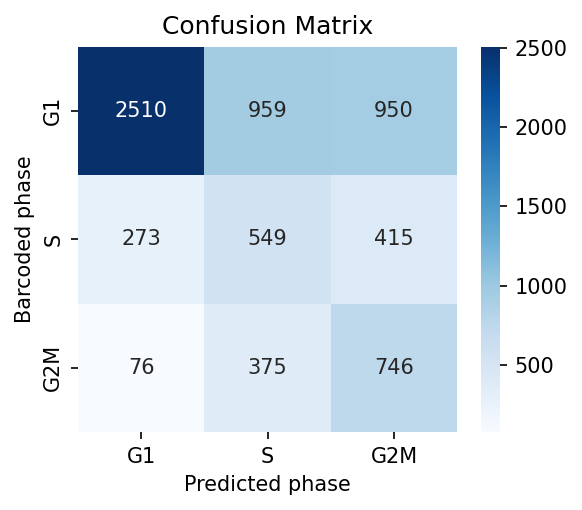

,G1,S,G2M
G1,0.568002,0.217017,0.214981
S,0.220695,0.443816,0.335489
G2M,0.063492,0.313283,0.623225


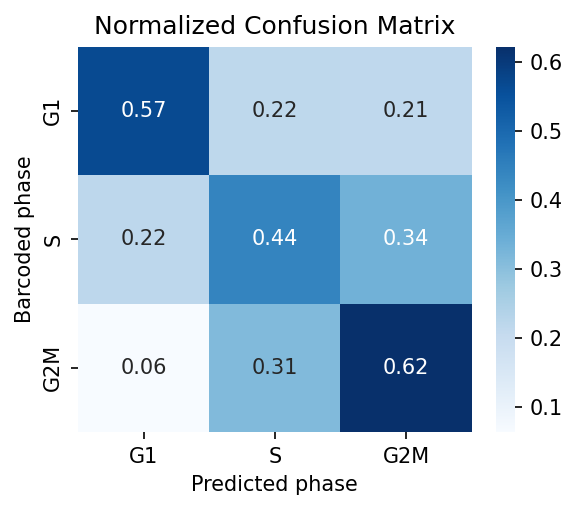

In [34]:
labels = ['G1', 'S', 'G2M'] #sorted(set(df["phase"]) | set(df["assigned_condition"]))

# Compute confusion matrix
cm = confusion_matrix(
    df["barcoded_phase"], # y_true
    df["cluster_phase"], # y_pred
    labels=labels
)

# Convert to DataFrame for nicer plotting
cdf = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

print(cdf.shape)
display(cdf)


plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cdf,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


cm_norm = confusion_matrix(
    df["barcoded_phase"],
    df["cluster_phase"],
    labels=labels,
    normalize="true"
)

cndf = pd.DataFrame(
    cm_norm,
    index=labels,
    columns=labels
)

display(cndf)

plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cndf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [35]:
labels = ['G1', 'S', 'G2M']

y_true = df['barcoded_phase']
y_pred = df['cluster_phase']  # or your saved predicted phase column

print(confusion_matrix(y_true, y_pred, labels=labels))
print(classification_report(y_true, y_pred, labels=labels))

print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Cohen kappa:", cohen_kappa_score(y_true, y_pred, labels=labels))
print("MCC:", matthews_corrcoef(y_true, y_pred))

[[2510  959  950]
 [ 273  549  415]
 [  76  375  746]]
              precision    recall  f1-score   support

          G1       0.88      0.57      0.69      4419
           S       0.29      0.44      0.35      1237
         G2M       0.35      0.62      0.45      1197

    accuracy                           0.56      6853
   macro avg       0.51      0.55      0.50      6853
weighted avg       0.68      0.56      0.59      6853

Balanced accuracy: 0.5450140739855023
Cohen kappa: 0.29129867287788547
MCC: 0.3127792819495854


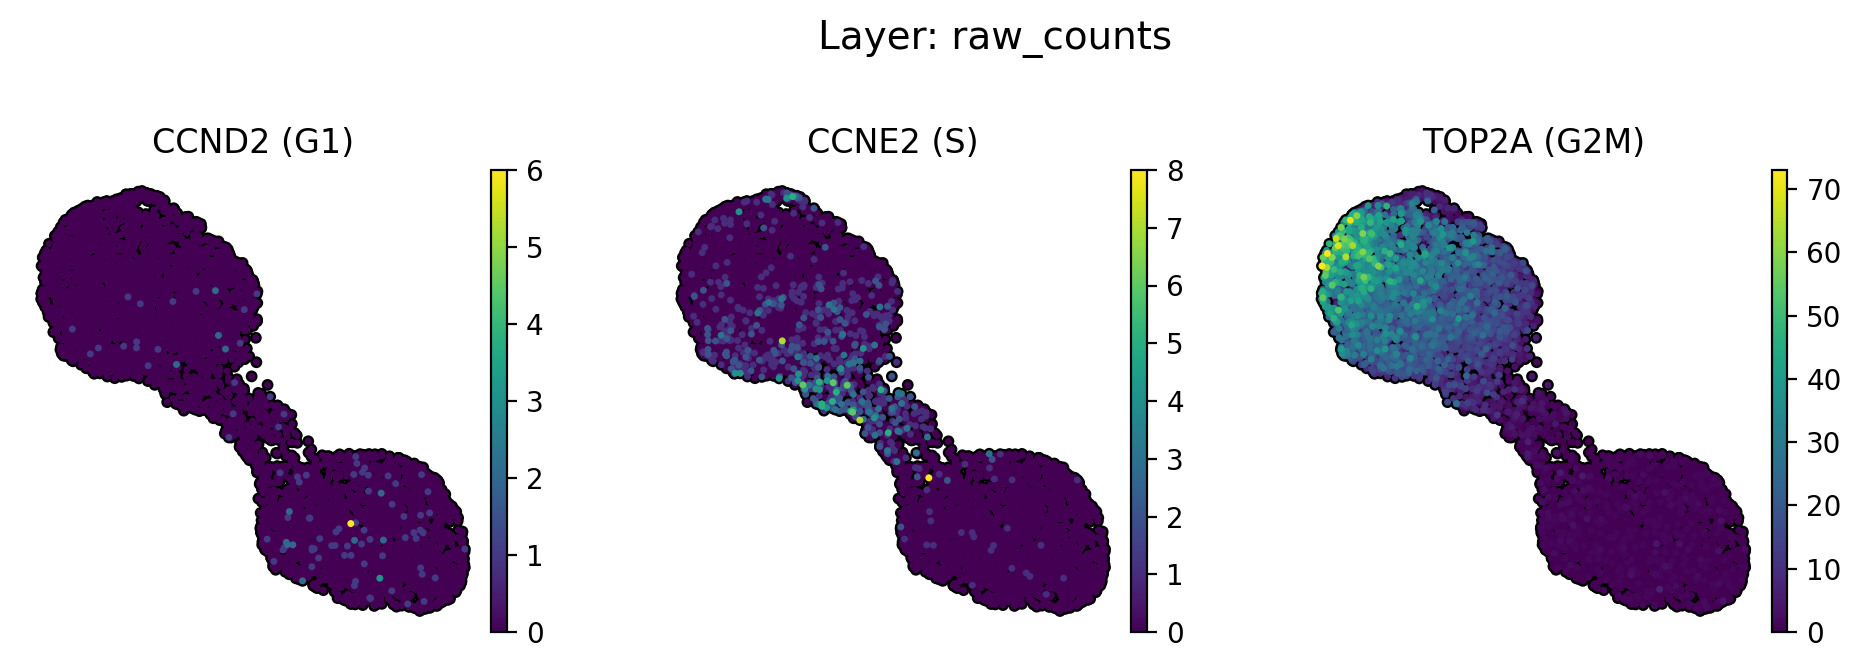

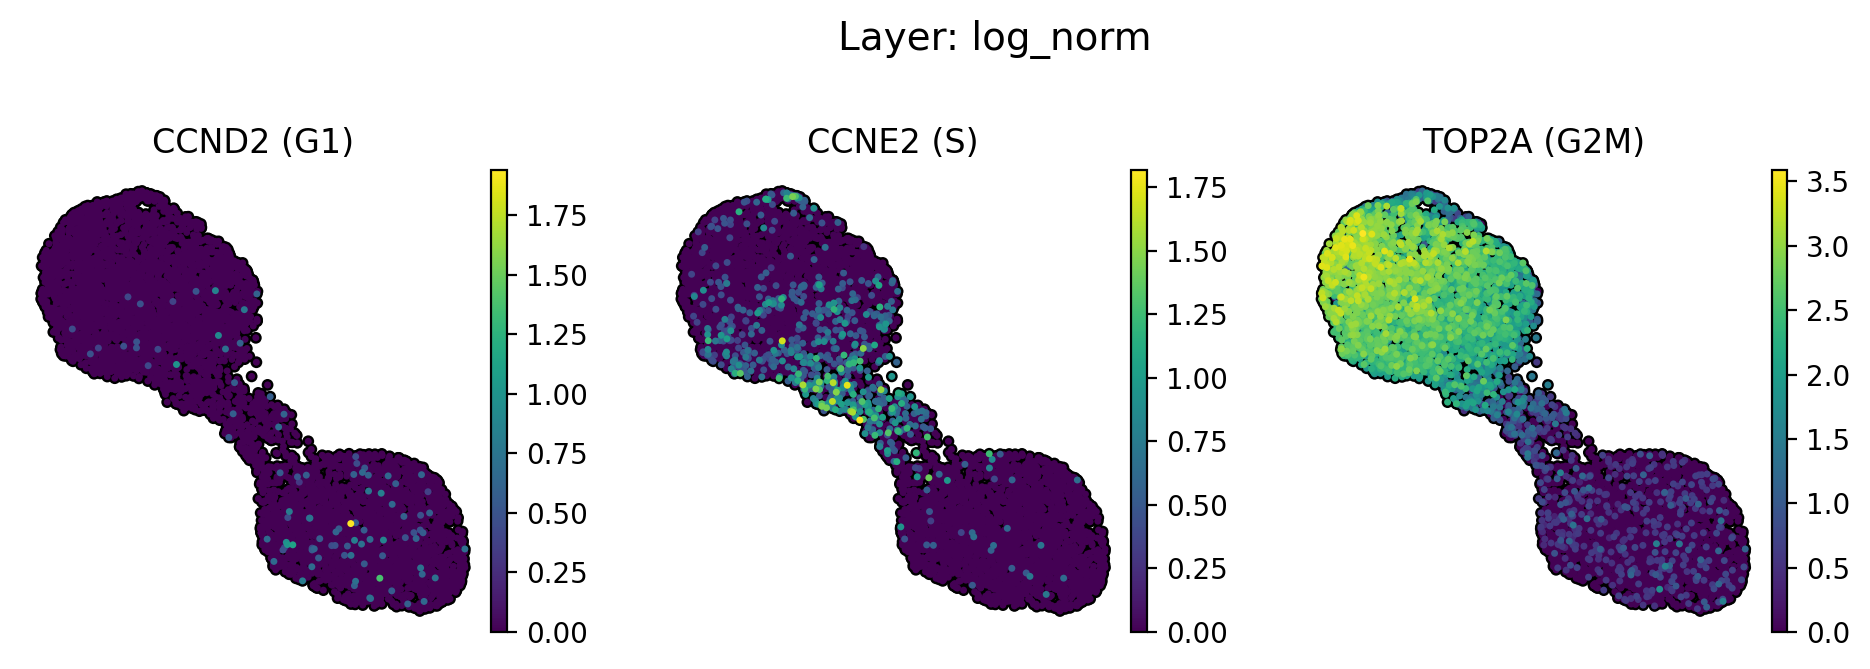

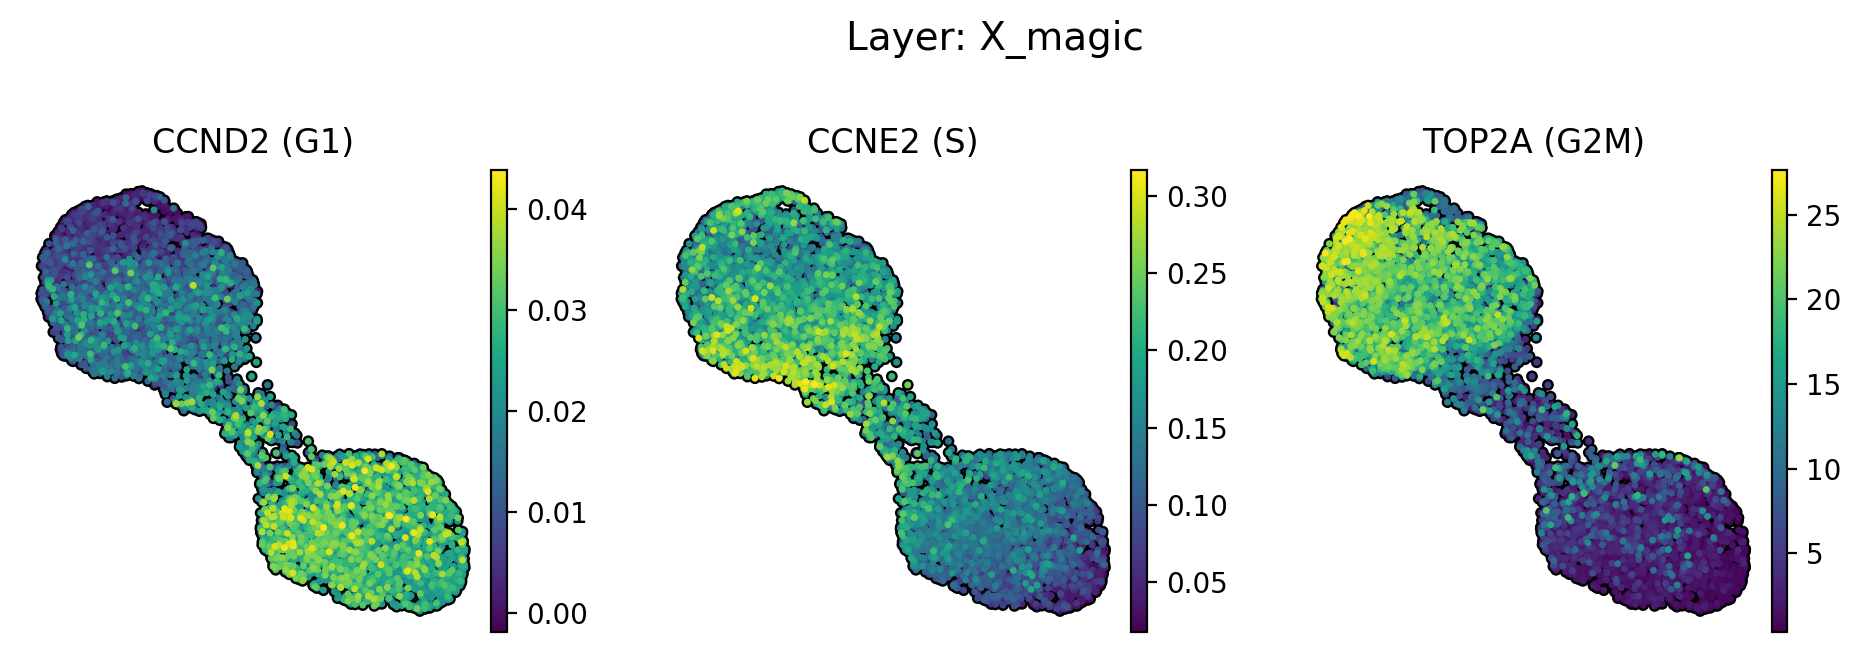

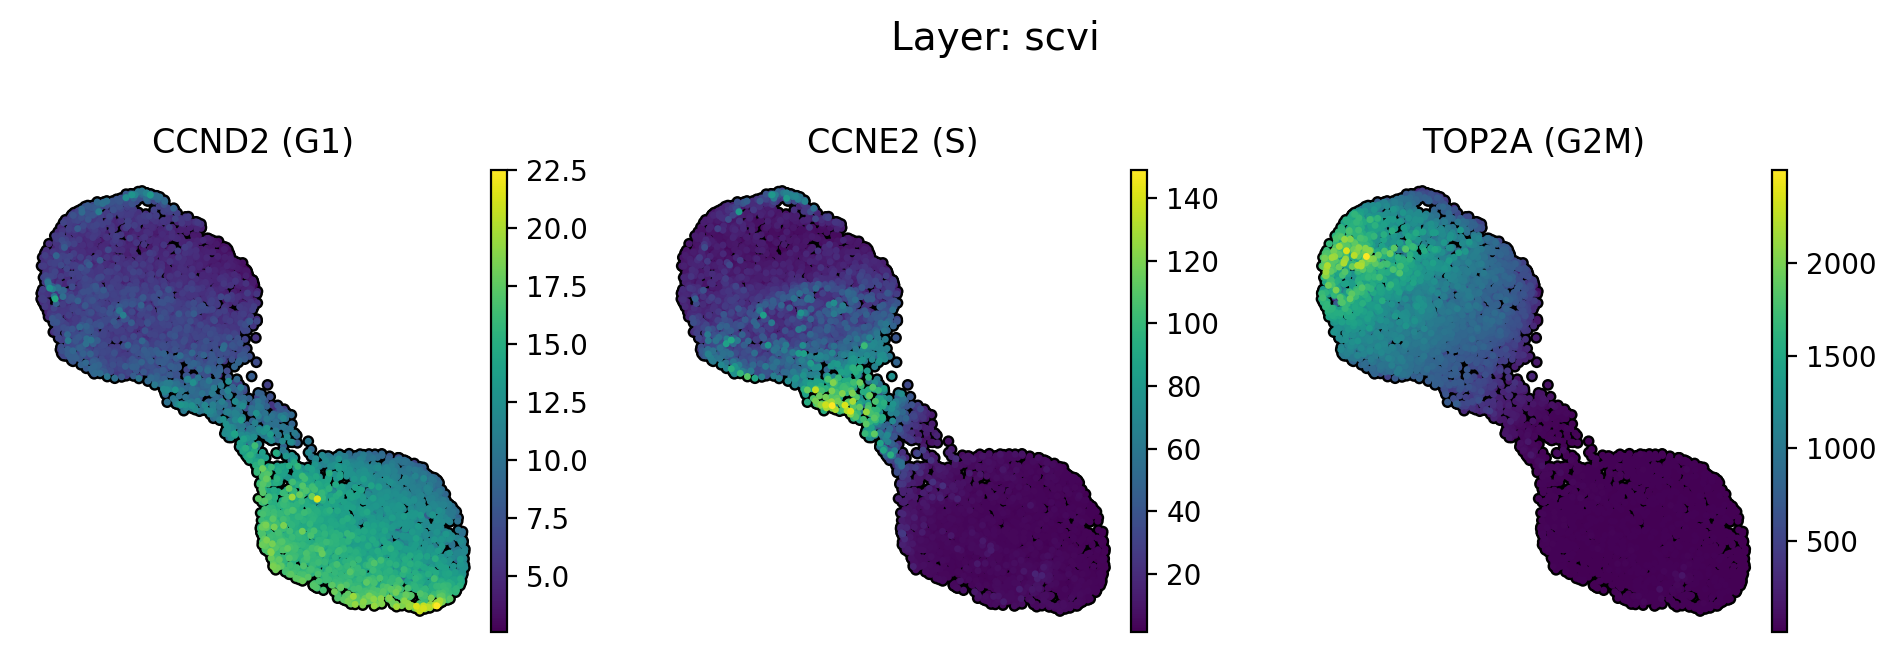

CPU times: user 2.75 s, sys: 169 ms, total: 2.92 s
Wall time: 2.98 s


In [20]:
%%time
genes = {
    "G1" : "CCND2",
    "S" : "CCNE2", 
    "G2M" : "TOP2A"  
}

titles = [f"{v} ({k})" for k, v in genes.items()]

for layer in ['raw_counts', 'log_norm',  'X_magic', 'scvi',]:


    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 3, 3
    
    axes = sc.pl.umap(
        adata,
        color=genes.values(),
        size=25,
        ncols=3,
        alpha=1,
        use_raw=False,
        layer=layer,
        add_outline=True,
        outline_color=('k', 'k'),
        title=titles,
        frameon=False,
        wspace=0.25,
        return_fig=True,   # <- important
    )
    
    axes.figure.suptitle(f"Layer: {layer}", fontsize=14, y=1.15)
    plt.show()

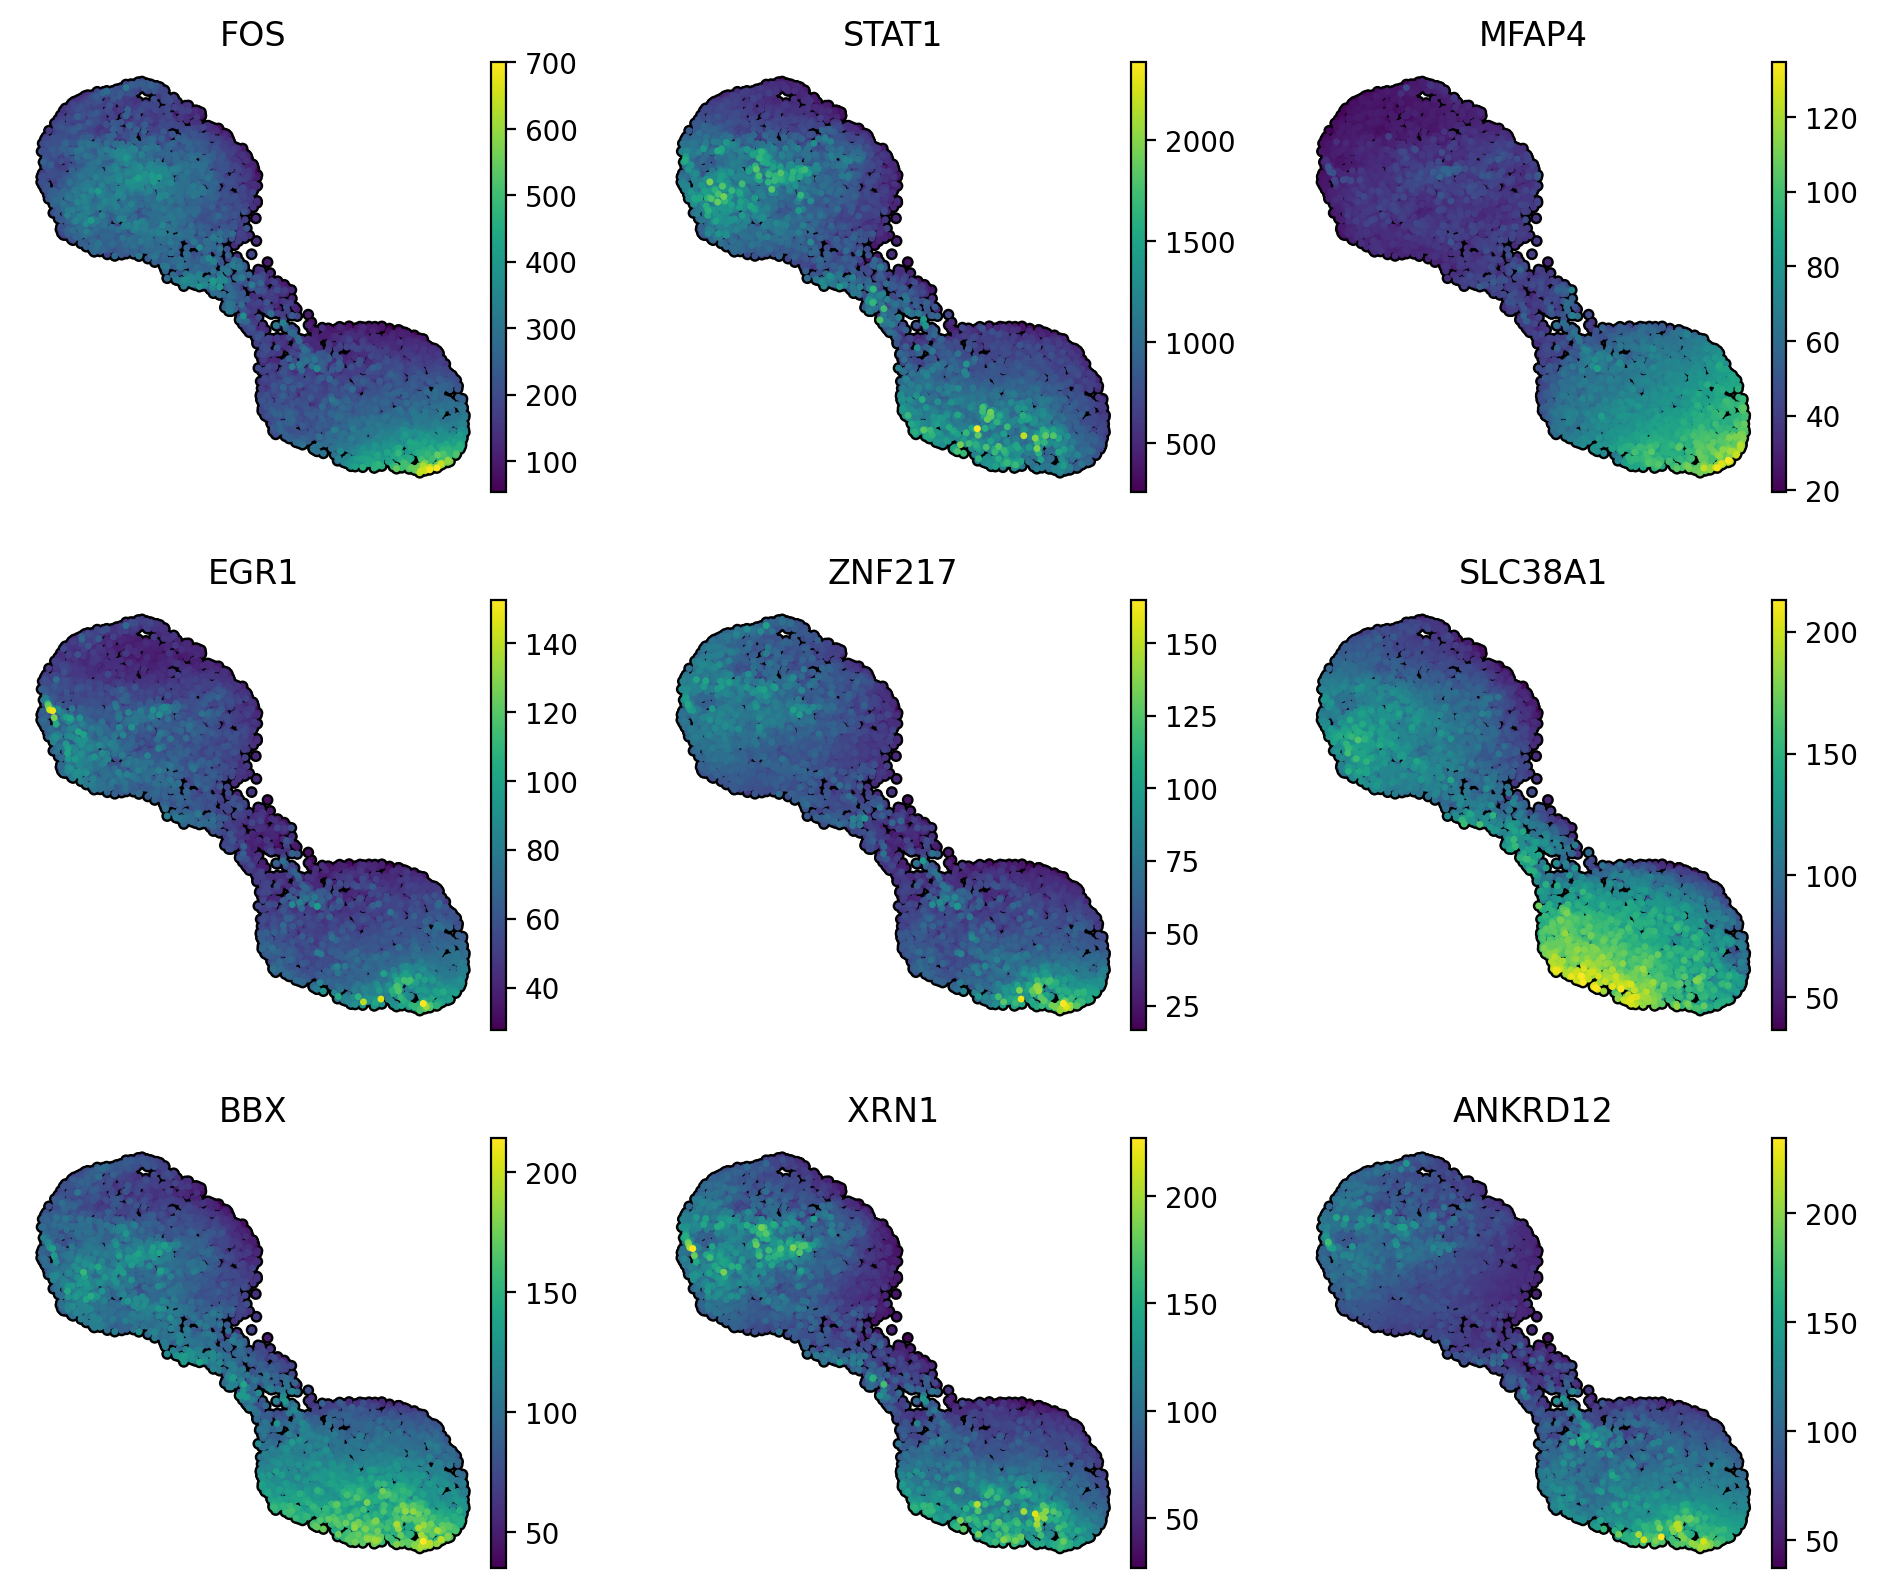

In [21]:
"""
Identify early G1 genes from: 
    M. J. Beyrouthy et al., “Identification of G1-Regulated Genes in Normally Cycling Human Cells,” PLOS ONE, vol. 3, no. 12, p. e3943, Dec. 2008

"""

genes = [
    "FOS", "STAT1", "MFAP4", "EGR1", "ZNF217",
    "SLC38A1","BBX","XRN1", "ANKRD12",
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=genes,
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    layer='scvi',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)


85th percentile threshold: -89.29737726726535
G1_stage
None     4013
late     2199
early     683
Name: count, dtype: int64


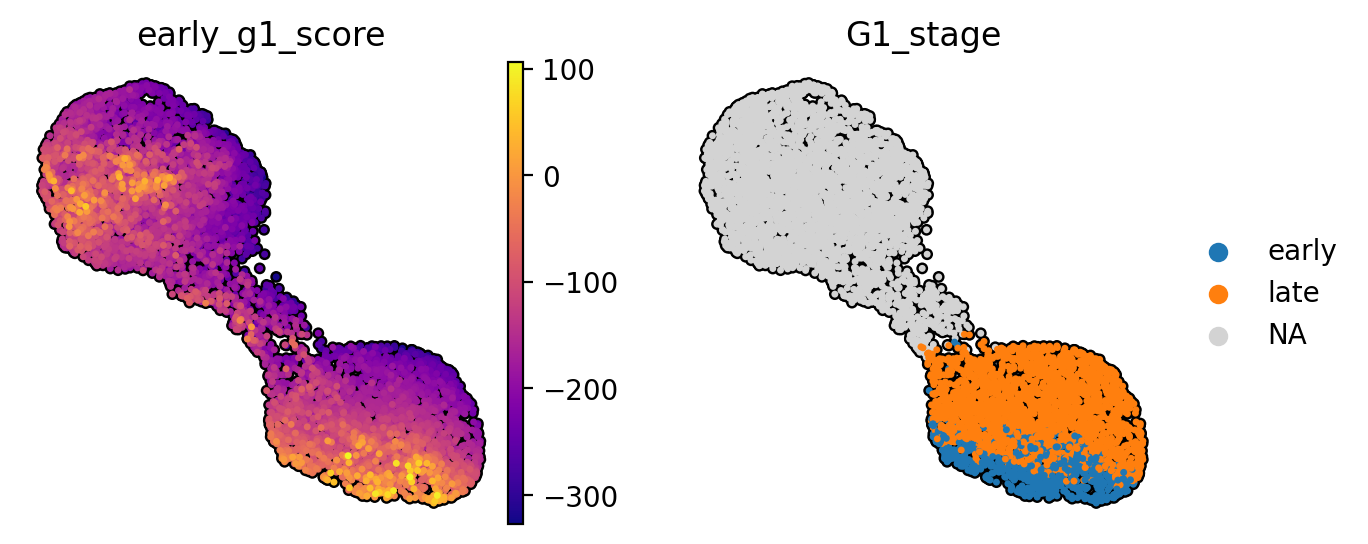

In [23]:
phase_column = 'cluster_phase' # could be cluster_phase instead

genes = [
    "FOS", "STAT1", "MFAP4", "EGR1", "ZNF217",
    "SLC38A1","BBX","XRN1", "ANKRD12",
]

# score cells by your gene set
sc.tl.score_genes(
    adata, 
    gene_list=genes,
    score_name="early_g1_score",
    use_raw=False,
    layer='scvi',
)

# compute threshold at the 85th percentile of the scores
threshold = np.percentile(adata.obs["early_g1_score"], 85)

# print threshold and distribution summary
print("85th percentile threshold:", threshold)

adata.obs["G1_stage"] = np.where(
    adata.obs[phase_column] == "G1",                       # only assign labels in G1
    np.where(adata.obs["early_g1_score"] > threshold, "early", "late"),
    None                                            # non-G1 cells
)

print(adata.obs["G1_stage"].value_counts(dropna=False))

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=['early_g1_score', 'G1_stage'],
    cmap='plasma',
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
)

In [26]:
def find_closest_cell(adata, obs_key='G1_stage', value='early', obsm_key='X_scvi'):
    """
    Find the cell closest to a median vector in PCA space.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group
        value (str): The value for aggregation 
        obsm_key (str): Key in adata.obsm for PCA or other embedding.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest G1 cell in adata.obs_names
    """
    mask = adata.obs[obs_key] == value
    emb = adata.obsm[obsm_key][mask]

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index

find_closest_cell(adata)

('CAAGCCACAGCCATCT-1', np.int64(1996))

cell_id='CAAGCCACAGCCATCT-1' root_idx=np.int64(1996)


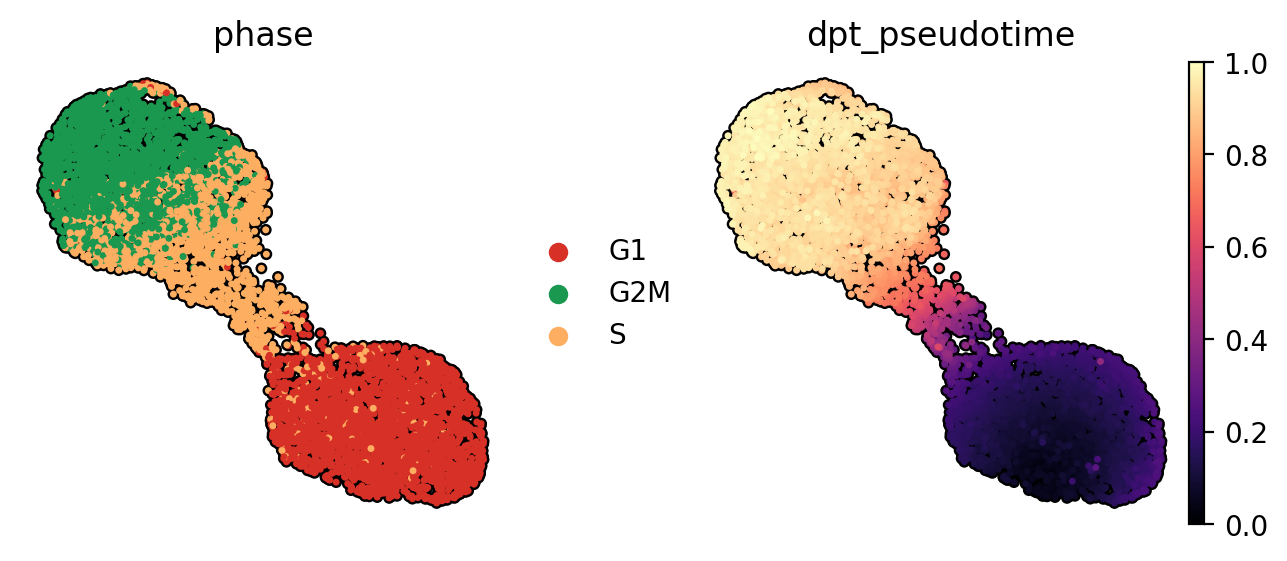

CPU times: user 5.78 s, sys: 292 ms, total: 6.07 s
Wall time: 6.79 s


In [27]:
%%time 
sc.pp.neighbors(adata, n_neighbors=75, use_rep='X_scvi')
sc.tl.diffmap(adata, n_comps=adata.obsm['X_scvi'].shape[1])

# choose representative cells from either G1 or G2M
cell_id, root_idx = find_closest_cell(
    adata, 
    obs_key='G1_stage', 
    value='early',
    obsm_key='X_scvi'
)

print(f"{cell_id=} {root_idx=}")

# set root and run pseudotime
adata.uns["iroot"] = root_idx
sc.tl.dpt(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata, 
    color=['phase', 'dpt_pseudotime'],
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    cmap='magma',
    add_outline=True,
    outline_color=('k', 'k'),
    palette=palette,
    frameon=False,
)

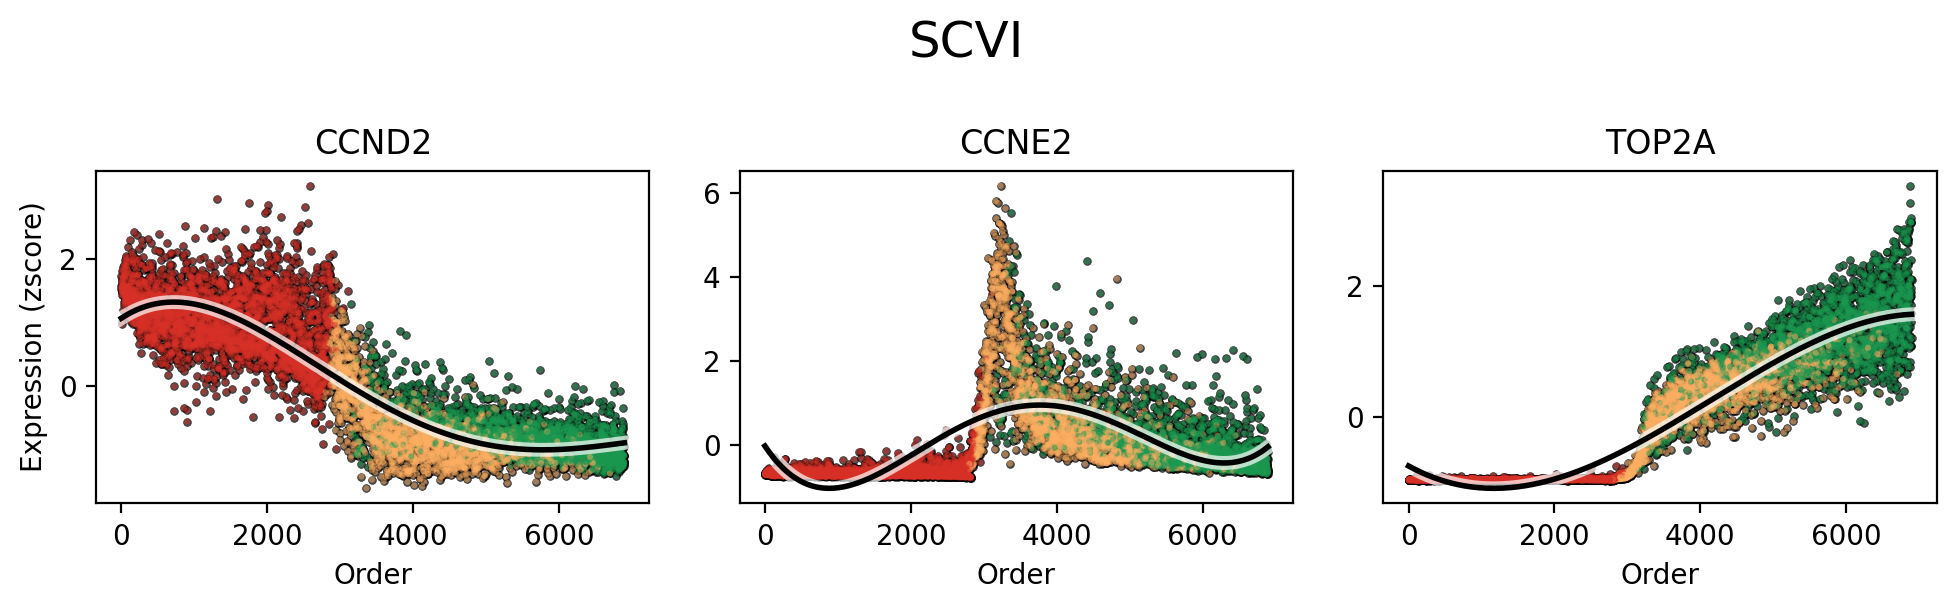

In [28]:
adata.obs['global_ordering'] = adata.obs['dpt_pseudotime'].rank(ascending=True)

palette = {
    "G1": "#D73027",        
    "S": "#FDAE61",       
    "G2M": "#1A9850",    
    "unknown": "#B0B0B0", 
}

layer = 'scvi'

gene_names = [
    "CCND2", "CCNE2",  "TOP2A"  
]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 3

fig, axes = plt.subplots(1, 3)
axes = axes.ravel()

for i, gene in enumerate(gene_names):
    y = adata[:, gene].layers[layer].ravel()
    y = zscore(y)
    x = adata.obs['global_ordering'].values

    sns.scatterplot(
        x=x,y=y,s=8,
        ec='k',c='k',
        alpha=0.7,
        ax=axes[i]
    )

    sns.scatterplot(
        x=x,y=y,s=5,
        ec='none',
        palette=palette,
        legend=False,
        alpha=0.5,
        hue=adata.obs[f'cluster_phase'],
        ax=axes[i]
    )
    axes[i].set_title(gene)
    axes[i].set_xlabel("Order")

    if i == 0:
        axes[i].set_ylabel("Expression (zscore)")

    # degree=4 polyfit
    coeffs = np.polyfit(x, y, deg=4)
    p = np.poly1d(coeffs)
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = p(x_fit)

    # error estimate from residuals
    residuals = y - p(x)
    err = residuals.std()
    y_lower = y_fit - err
    y_upper = y_fit + err

    axes[i].plot(x_fit, y_fit, lw=5, color="w", alpha=0.7)
    axes[i].plot(x_fit, y_fit, lw=2, color="k")
    # axes[i].fill_between(x_fit, y_lower, y_upper, color="k", alpha=0.2)

fig.suptitle(layer.upper(), fontsize=18, y=1.0)
plt.tight_layout()

In [31]:
df = adata.obs[['cluster_phase', 'barcoded_phase', 'G1_stage', 'dpt_pseudotime', 'global_ordering']].copy()


# df.to_csv("scfib_pseudotime_cooper.csv")

print(df.shape)
df.head()

(6895, 5)


,cluster_phase,barcoded_phase,G1_stage,dpt_pseudotime,global_ordering
AAACCAAAGGGTAGCA-1,S,G2M,NaN,0.910904,4893.0
AAACCAAAGTAAGGGT-1,G1,G1,late,0.101642,881.0
AAACCATTCAGGTAGG-1,G2M,G1,NaN,0.967784,6694.0
AAACCATTCCAGCCCT-1,G1,S,late,0.201039,2530.0
AAACCATTCGTGACCG-1,G1,G1,early,0.066694,344.0


In [4]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()

# filter for Control cells
adata = adata[adata.obs['dataset'] == 'Control', :].copy()

adata

/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


Memory usage: current 1.49 GB, difference +0.50 GB
CPU times: user 248 ms, sys: 727 ms, total: 975 ms
Wall time: 1.45 s


AnnData object with n_obs × n_vars = 8963 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

In [5]:
# drop unlabeled cells
cells_to_remove = adata.obs['assigned_condition'].isna()
adata = adata[~(cells_to_remove)].copy()

adata

AnnData object with n_obs × n_vars = 8875 × 28702
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End'

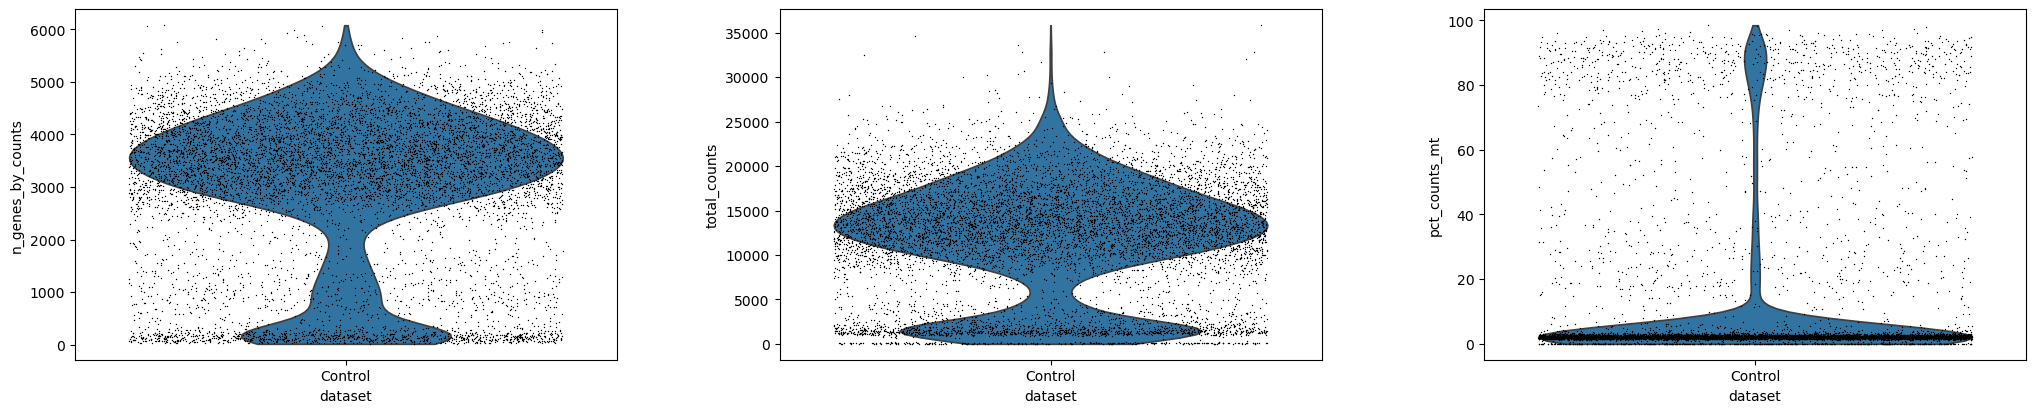

In [6]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='dataset',
)

In [7]:
from scipy.stats import median_abs_deviation

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]

    if len(M) < 2 or M.isnull().all():
        return pd.Series(False, index=adata.obs.index)

    median_val = np.median(M)
    mad_val = median_abs_deviation(M)

    if mad_val == 0:
        return pd.Series(False, index=adata.obs.index)

    outliers = (M < median_val - nmads * mad_val) | \
               (M > median_val + nmads * mad_val)

    return outliers



adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
)

print("Number of outlier cells based on counts:")
print(adata.obs["outlier"].sum())

adata.obs["mt_outlier"] = (
    is_outlier(adata, "pct_counts_mt", 5)
    | (adata.obs["pct_counts_mt"] > 20)
)

print("\nNumber of outlier cells based on pct mito:")
print(adata.obs["mt_outlier"].sum())

init_cells = adata.n_obs
print(f"Total number of cells: {init_cells}")

print("\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs

print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"\nTotal cells after filtering of low quality cells: {final_cells}")

Number of outlier cells based on counts:
1649

Number of outlier cells based on pct mito:
1822
Total number of cells: 8875

Filtering...

Removed 1960 total cells.

Total cells after filtering of low quality cells: 6915


In [8]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()

print("Filtering genes...\n")

sc.pp.filter_genes(adata, min_counts=10)


print("\nNormalizing counts to 10,000...\n")
sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

Filtering genes...


Normalizing counts to 10,000...



AnnData object with n_obs × n_vars = 6915 × 19983
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'dataset_colors', 'log1p'
    layers: 'raw_counts', 'log_norm'

Number of HVG: 3000


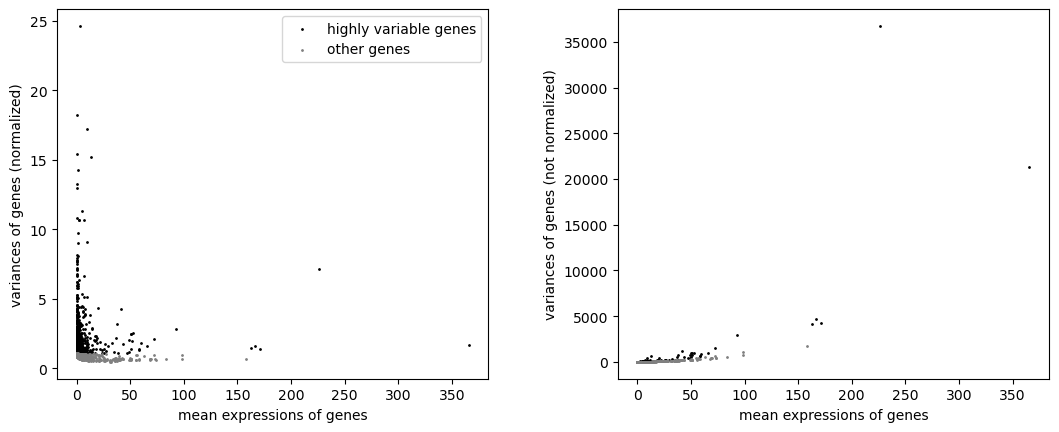

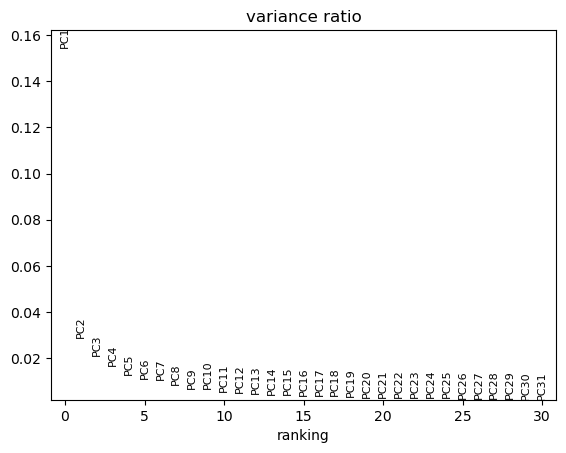

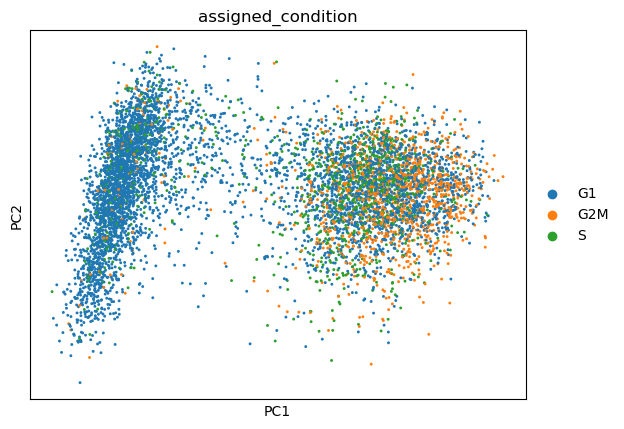

AnnData object with n_obs × n_vars = 6915 × 19983
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_colors', 'log1p', 'hvg', 'pca', 'assigned_condition_col

In [9]:
### HVGs
adata.X = adata.layers['raw_counts'].copy()

# automatically scales the data
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    n_top_genes=3000,
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)


adata.X = adata.layers['log_norm'].copy()

### PCA with HVGs
sc.pp.pca(
    adata,
)

sc.pl.pca_variance_ratio(adata)

sc.pl.pca(
    adata, 
    color=['assigned_condition'],
)

adata

phase
G2M    0.500362
G1     0.481851
S      0.017787
Name: proportion, dtype: float64


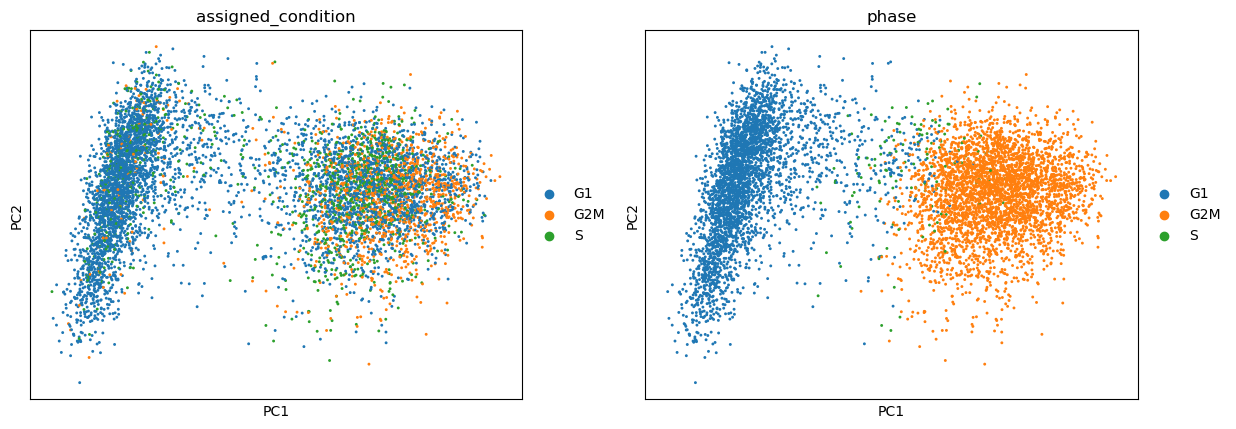

CPU times: user 976 ms, sys: 548 ms, total: 1.52 s
Wall time: 1.55 s


In [13]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

# sc.pp.scale(adata)

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

print(adata.obs['phase'].value_counts(normalize=True))

sc.pl.pca(
    adata, 
    color=['assigned_condition', 'phase'],
    ncols=2,
)

In [11]:
adata.obs['phase'].value_counts(normalize=True)

phase
G2M    0.500362
G1     0.481851
S      0.017787
Name: proportion, dtype: float64

In [ ]:
sc.pp.neighbors(
    adata,
    n_neighbors=10, 
)

sc.tl.umap(adata)


sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor='igraph',
)

plt.rcdefaults()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    bdata,
    color=['assigned_condition', 'phase', 'leiden', 'log1p_total_counts', 'pct_counts_mt'],
    size=15,
    ncols=3,
    # add_outline=True,
    # outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)